# Unmixing_2: autoencoders

In this session, we will use a small autoencoder described in:  
> Palsson, B., Sigurdsson, J., Sveinsson, J. R., & Ulfarsson, M. O. (2018). Hyperspectral unmixing using a neural network autoencoder. IEEE Access, 6, 25646-25656.
https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8322133

The code is my own implementation, so it is slightly different from what is included in https://github.com/burknipalsson/hu_autoencoders, but the architecture remains the same. The code is written in a deliberately explicit way to illustrate each step, although in practice the same workflow could be implemented much more compactly, for example with a dedicated DataLoader.

Unlike in conventional supervised learning, the goal here is to use the neural network as a computational framework to perform the unmixing itself.
In other words, the network serves primarily as an optimization formalism, finding a compact and physically consistent latent representation of the spectra.

What makes this approach special — and somewhat counterintuitive if you already know a bit of deep learning — is that the network is trained on the same hyperspectral image that we want to unmix.
We do not need any large external training dataset.
Instead, the autoencoder learns a compact internal representation of the image itself, capturing its main spectral components in an unsupervised way.

To keep the training under control, we still set aside a small validation subset of pixels. This helps us monitor the training process and make sure the model is not just memorizing the data but actually learning useful spectral features.

Finally, note that this architecture does not take into account the spatial structure of the hyperspectral image. The data are used in the form of a simple 2D array with shape (number of pixels, number of energy channels). Each spectrum is processed independently, and spatial correlations are ignored in this first approach.


⚠️ Note: This notebook uses an older Keras/TensorFlow implementation originally developed on Windows.
Since Keras is no longer actively supported on Windows, reproducing the exact environment may cause installation issues or dependency conflicts.

⚙️ **Environment used:**  
- Python 3.9.4 
- numpy 1.19.5  
- SciPy version: 1.6.2  
- TensorFlow version: 2.5.0 
- Keras version: 2.5.0 

In [1]:
import keras
import tensorflow as tf

from keras import regularizers
from keras.initializers import Constant
from tensorflow.keras import layers
from tensorflow.keras import activations
from tensorflow.keras import losses
from tensorflow.keras import metrics
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import Model, initializers as init, optimizers

import os
import scipy.io
from scipy.io import loadmat
import numpy as np
import math
import matplotlib.pyplot as plt
import random

In [2]:
# Fix Python, NumPy, and TensorFlow seeds
SEED = 2025
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seeds fixed:", SEED)

Seeds fixed: 2025


## 0. Sanity check (spectra side-by-side).  

During implementation I used a small helper to plot two series of spectra, typically the original inputs and their reconstructions, to verify that the network really maps a given hyperspectral image to a spectrally close one. The function samples a few pixel indices, overlays input vs. reconstructed spectra, and labels each subplot with the pixel id. It’s a quick visual check that the autoencoder preserves peak positions/shapes rather than memorizing noise.  

But be careful, the fact that the network has a nice spectrum as output doesn't always signify that everything went well !

In [3]:
def display(spim1, spim2, n=16, seed=None):
    """
    Display n random spectra from both arrays side by side.
    Each column = same pixel index, top = input, bottom = reconstruction.
    """
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(spim1), size=n, replace=False)

    plt.figure(figsize=(2*n, 4))
    for i, idx in enumerate(indices):
        # top row = input
        ax = plt.subplot(2, n, i+1)
        ax.plot(spim1[idx])
        ax.set_title(f"idx {idx}", fontsize=8)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # bottom row = recon
        ax = plt.subplot(2, n, i+1+n)
        ax.plot(spim2[idx])
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.suptitle("Input vs Reconstruction (same indices)", y=1.05)
    plt.tight_layout()
    plt.show()


## 1. Prepare the data  

*Note on input format*  

Originally, hyperspectral remote sensing data (and many reference codes) were distributed in MATLAB `.mat` files. That’s why this implementation starts by reading `.mat`: it ensures compatibility with existing tutorials and benchmark datasets.

In practice, EELS/hyperspectral data are often stored in NumPy `.npy` arrays or in HyperSpy `.hspy` files. To make the workflow flexible, we can define a single loader that tries to detect the file type.

In [4]:
try:
    import hyperspy.api as hs
    HAS_HYPERSPY = True
except ImportError:
    HAS_HYPERSPY = False

def load_spectral_data(path):
    """
    Load hyperspectral data from .mat, .npy, or .hspy file.
    Returns array of shape (N, D) where
      N = number of spectra (pixels)
      D = number of channels (energy bands)
    """
    ext = os.path.splitext(path)[1].lower()

    if ext == ".mat":
        md = loadmat(path)
        # md is a dictionary
        # if needed you can check the keys with:
        # print(md.keys())
        if "Y" in md:  # common convention (B, P)
            Y = md["Y"]
            if Y.shape[0] < Y.shape[1]:  # (bands, pixels)
                Y = Y.T
        elif "Spim" in md:  # another common convention (B, P)
            Y = md["Spim"]
            
        else:
            raise ValueError("No 'Y' or 'Spim' variable found in .mat file")
        return Y

    elif ext == ".npy":
        arr = np.load(path)
        return arr

    elif ext == ".hspy":
        if not HAS_HYPERSPY:
            raise ImportError("HyperSpy not installed")
        s = hs.load(path)
        data = s.data  # shape (lines, cols, bands)
        return data

    else:
        raise ValueError(f"Unknown file extension: {ext}")


In [5]:
# ⚠️ MODIFY this line according to your own path
# 2 data sets are provided, Sub21bisSpim03_50ms.mat and Sub21terSpim03_50ms.mat
# Sub21bisSpim03_50ms.mat is a subset of Sub21terSpim03_50ms.mat
path_data = r'C:\Users\brun\Documents\AutumnSchool_AI_in_Electron_Microscopy2025_Autoencoders\Data\Sub21bisSpim03_50ms.mat'
img = load_spectral_data(path_data)

It is important to check the cube dimensions right after loading. Depending on the file format, axes may be transposed or reshaped. We want to import the data in the initial 3D form (pixels, pixels, bands)  

Printing `(n_lines, n_rows, n_bands)` helps to ensure that the data were imported in the expected orientation, avoiding subtle mistakes in the following steps (⚠️ this is a very common source of errors).

In [6]:
numRows = img.shape[0]
numCols = img.shape[1]
numBands = img.shape[2]
numPixels = numRows*numCols

print(f"Data cube loaded:")
print(f"  - data cube shape = {img.shape}")
print(f"  - n_lines = {numRows}")
print(f"  - n_rows  = {numCols}")
print(f"  - n_bands = {numBands}")

Data cube loaded:
  - data cube shape = (60, 75, 200)
  - n_lines = 60
  - n_rows  = 75
  - n_bands = 200


In [7]:
# after checking the loaded data we can perform data flattening
img_flat = img.reshape((numPixels, numBands))

**Normalization strategies**  

Neural networks are very sensitive to the scale of their inputs. If spectra contain very large or heterogeneous numerical values, training may become unstable or biased. This is why it is essential to normalize hyperspectral data before feeding them to an autoencoder.

Two common normalization strategies are:

- $L_1$ normalization (sum-to-1): each spectrum is divided by the sum of its intensities. This ensures that all spectra have unit $L_1$ norm, which is consistent with the abundance constraint in spectral unmixing (abundances sum to one). However, in practice this can lead to abundance maps that look almost binary, with values close to 0 or 1.

- Min–max normalization (per spectrum): each spectrum is rescaled to the range [0, 1] using its own minimum and maximum. This approach emphasizes the relative shape of each spectrum and often produces smoother, less binary abundance maps. The drawback is that absolute intensity information between spectra is lost.

In this notebook we keep both options available. $L_1$ normalization is theoretically closer to the physical model of unmixing, while min–max normalization is sometimes more convenient for visualization and interpretation.

In [8]:
# The *min–max per spectrum* option used here follows the implementation from
# `deephyp` (L. Windrim et al.): https://github.com/lloydwindrim/hyperspectral-autoencoders/tree/master/deephyp


def normalize_spectra(X, mode="minmax", eps=1e-12):
    """
    X: (N, D) spectra. Return X_norm of same shape.
    mode: 'l1' (sum-to-1) or 'minmax' (per-spectrum to [0,1]).
    """
    if mode == "l1":
        s = X.sum(axis=1, keepdims=True) + eps
        Xn = X / s
        # quick check
        row_sums = Xn.sum(axis=1)
        print(f"[l1] mean={row_sums.mean():.6f}, std={row_sums.std():.2e}, "
              f"range=({row_sums.min():.6f}, {row_sums.max():.6f})")
        return Xn

    elif mode == "minmax":
        x_min = X.min(axis=1, keepdims=True)
        x_max = X.max(axis=1, keepdims=True)
        Xn = (X - (x_min - 1e-3)) / (x_max + eps)  # mirrors your legacy code
        # values should be ≈ in [0,1]; we report basic stats
        print(f"[minmax] min={Xn.min():.6f}, max={Xn.max():.6f}")
        return Xn

    else:
        raise ValueError("mode must be 'l1' or 'minmax'")

# usage:
# X_norm = normalize_spectra(X, mode="l1")      
# X_norm = normalize_spectra(X, mode="minmax")  

In [9]:
img_flat_norm = normalize_spectra(img_flat)

[minmax] min=0.000000, max=0.961354


**Why shuffle the data?**

After loading the hyperspectral cube, we reshape it into a 2D array (N, D) where each row is a pixel spectrum. Before splitting into training and validation sets, it is important to shuffle the rows. This avoids having the validation set biased toward a specific region of the image (for example, one side of the field of view). Shuffling ensures that both train and validation subsets are representative of the whole image.

In [12]:
def shuffle(data):
    """ Randomly permutes all dataSamples (and corresponding targets).
    """
    idx = np.random.permutation(np.shape(data)[0])
    dataSamples = data[idx,:]
    return dataSamples

In [13]:
img_flat_shuffled = shuffle(img_flat_norm)

In [14]:
# now we select a train set and a val/test set
# all these steps can be included in a dataloader function providing an input with the convenient shape
# we separate the lines off code for clarity

trainSamples = math.floor(numPixels * .95)
valSamples = numPixels - trainSamples
train_data = img_flat_shuffled[:trainSamples, :]
test_data = img_flat_shuffled[trainSamples:, :]

In [15]:
train_data.shape

(4275, 200)

## 2 : Deep autoencoder

In [16]:
def build_autoencoder(num_bands: int, R: int = 3, init_mode: str = "glorot") -> Model:
    """
    Build an autoencoder for spectral unmixing.

    Parameters
    ----------
    num_bands : int
        Number of spectral channels (input dimension).
    R : int
        Number of endmembers (latent dimension).
    init_mode : str
        Weight initializer for Dense layers.
        Options: "glorot" (glorot_uniform, default),
                 "he"     (he_normal),
                 "lecun"  (lecun_normal).

    Returns
    -------
    keras.Model
        Compiled autoencoder model.
    """
   # Map init_mode to Keras initializers
    if init_mode == "glorot":
        kernel_init = "glorot_uniform"
    elif init_mode == "he":
        kernel_init = "he_normal"
    elif init_mode == "lecun":
        kernel_init = "lecun_normal"
    else:
        raise ValueError("init_mode must be 'glorot', 'he', or 'lecun'")


    inp = layers.Input(shape=(num_bands,), name="input")

    # ----- Encoder -----
    x = layers.Dense(9*R, kernel_initializer=kernel_init, name="enc_dense_9R")(inp)
    x = layers.LeakyReLU(alpha=0.2, name="enc_lrelu_9R")(x)

    x = layers.Dense(6*R, kernel_initializer=kernel_init, name="enc_dense_6R")(x)
    x = layers.LeakyReLU(alpha=0.2, name="enc_lrelu_6R")(x)

    x = layers.Dense(3*R, kernel_initializer=kernel_init, name="enc_dense_3R")(x)
    x = layers.LeakyReLU(alpha=0.2, name="enc_lrelu_3R")(x)

    x = layers.Dense(R, kernel_initializer=kernel_init, name="enc_dense_R")(x)
    x = layers.LeakyReLU(alpha=0.2, name="enc_lrelu_R")(x)

    # BatchNorm + sparsity-enhancing PReLU, then simplex via Softmax
    x = layers.BatchNormalization(name="enc_bn")(x)
    x = layers.PReLU(alpha_initializer=init.Constant(0.25), name="enc_prelu")(x)
    x = layers.Softmax(name="abundances_softmax")(x)           # (batch, R), sum=1
    x = layers.GaussianDropout(rate=0.01, name="enc_gdrop")(x) # light regularization

    # ----- Decoder (linear reconstruction) -----
    out = layers.Dense(num_bands, kernel_initializer=kernel_init, name="recon_linear")(x)

    ae = Model(inp, out, name="AE_unmixing")
    
    return ae

# usage
# autoencoder = build_autoencoder(num_bands=numBands, R=3)
# autoencoder = build_autoencoder((num_bands=train_data.shape[1], R=3, init_mode=init_mode)
# autoencoder.summary()


In [17]:
autoencoder = build_autoencoder(num_bands=numBands, R=3, init_mode="lecun")
autoencoder.summary()

Model: "AE_unmixing"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input (InputLayer)           [(None, 200)]             0         
_________________________________________________________________
enc_dense_9R (Dense)         (None, 27)                5427      
_________________________________________________________________
enc_lrelu_9R (LeakyReLU)     (None, 27)                0         
_________________________________________________________________
enc_dense_6R (Dense)         (None, 18)                504       
_________________________________________________________________
enc_lrelu_6R (LeakyReLU)     (None, 18)                0         
_________________________________________________________________
enc_dense_3R (Dense)         (None, 9)                 171       
_________________________________________________________________
enc_lrelu_3R (LeakyReLU)     (None, 9)                 

**Loss functions and noise assumptions**

- **MSE (Mean Squared Error)**  
  Minimizing MSE is equivalent to assuming Gaussian additive noise.  
  This is the default choice in many autoencoder implementations, but it does not match the Poisson statistics of EELS spectra.  

- **SAD (Spectral Angle Distance)**  
  The spectral angle is a purely geometric criterion: it compares the *shape* of spectra by measuring the angle between them, after normalization.  
  It does **not** rely on any explicit noise model (neither Gaussian nor Poisson).  
  The trade-off is that amplitude information is ignored — only the relative spectral features are emphasized.  

👉 In this notebook we used **SAD loss**, which avoids making assumptions on the noise distribution and focuses on spectral similarity.


In [18]:
# Definition of a custom loss function
# from : https://github.com/lloydwindrim/hyperspectral-autoencoders/blob/master/deephyp/network_ops.py

def loss_function_reconstruction_1D(y_reconstructed,y_target,func='SA'):
    """ Reconstruction loss function op, comparing 1D tensors for network reconstruction and target.
    Args:
        y_reconstructed (tensor): Output of network (reconstructed 1D vector). Shape [numSamples x inputSize].
        y_target (tensor): What the network is trying to reconstruct (1D vector). Shape [numSamples x inputSize].
        func (string): The name of the loss function to be used. 'SSE'-sum of square errors,'CSA'-cosine spectral angle, \
            'SA'-spectral angle, 'SID'-spectral information divergence.
    """
    if func == 'SSE':
        # sum of squared errors loss
        loss = tf.reduce_sum( tf.square(y_target - y_reconstructed) )

    elif func == 'CSA':
        # cosine of spectral angle loss
        normalize_r = tf.math.l2_normalize(tf.transpose(y_reconstructed),axis=0)
        normalize_t = tf.math.l2_normalize(tf.transpose(y_target),axis=0)
        loss = tf.reduce_sum( 1 - tf.reduce_sum(tf.multiply(normalize_r, normalize_t),axis=0 ) )

    elif func == 'SA':
        # spectral angle loss
        normalize_r = tf.math.l2_normalize(tf.transpose(y_reconstructed),axis=0)
        normalize_t = tf.math.l2_normalize(tf.transpose(y_target),axis=0)
        loss = tf.reduce_sum( tf.math.acos(tf.reduce_sum(tf.multiply(normalize_r, normalize_t),axis=0 ) ) )

    elif func == 'SID':
        # spectral information divergence loss
        t = tf.divide( tf.transpose(y_target) , tf.reduce_sum(tf.transpose(y_target),axis=0) )
        r = tf.divide( tf.transpose(y_reconstructed) , tf.reduce_sum(tf.transpose(y_reconstructed),axis=0) )
        loss = tf.reduce_sum( tf.reduce_sum( tf.multiply(t,tf.log(tf.divide(t,r))) , axis=0)
                              + tf.reduce_sum( tf.multiply(r,tf.log(tf.divide(r,t))) , axis=0) )
    else:
        raise ValueError('unknown loss function: %s. Use SSE, CSA, SA or SID.' % func)

    return loss

We add a learning rate scheduler that reduces the LR when the validation loss stops improving.  
The training uses:
- `EarlyStopping` to prevent overfitting and restore the best model
- `ModelCheckPoint` to save the best weights during training
- `ReduceLROnPlateau` to lower the LR when progress stalls (stabilizes val_loss)

In [19]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint("runs/ae_best.h5", monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

autoencoder.compile(optimizer=optimizers.Adam(1e-3), loss=loss_function_reconstruction_1D)


history = autoencoder.fit(x=train_data, y=train_data, epochs=30, batch_size = 5, shuffle=True, validation_data = (test_data, test_data), callbacks = callbacks, verbose = 1)


Epoch 1/30
855/855 [==============================] - 2s 1ms/step - loss: 2.1361 - val_loss: 0.3393

Epoch 00001: val_loss improved from inf to 0.33928, saving model to runs\ae_best.h5
Epoch 2/30
855/855 [==============================] - 1s 830us/step - loss: 0.5135 - val_loss: 0.3645

Epoch 00002: val_loss did not improve from 0.33928
Epoch 3/30
855/855 [==============================] - 1s 838us/step - loss: 0.4484 - val_loss: 0.3372

Epoch 00003: val_loss improved from 0.33928 to 0.33722, saving model to runs\ae_best.h5
Epoch 4/30
855/855 [==============================] - 1s 832us/step - loss: 0.4101 - val_loss: 0.3400

Epoch 00004: val_loss did not improve from 0.33722
Epoch 5/30
855/855 [==============================] - 1s 814us/step - loss: 0.3701 - val_loss: 0.3954

Epoch 00005: val_loss did not improve from 0.33722
Epoch 6/30
855/855 [==============================] - ETA: 0s - loss: 0.283 - 1s 752us/step - loss: 0.2822 - val_loss: 0.3586

Epoch 00006: val_loss did not impro

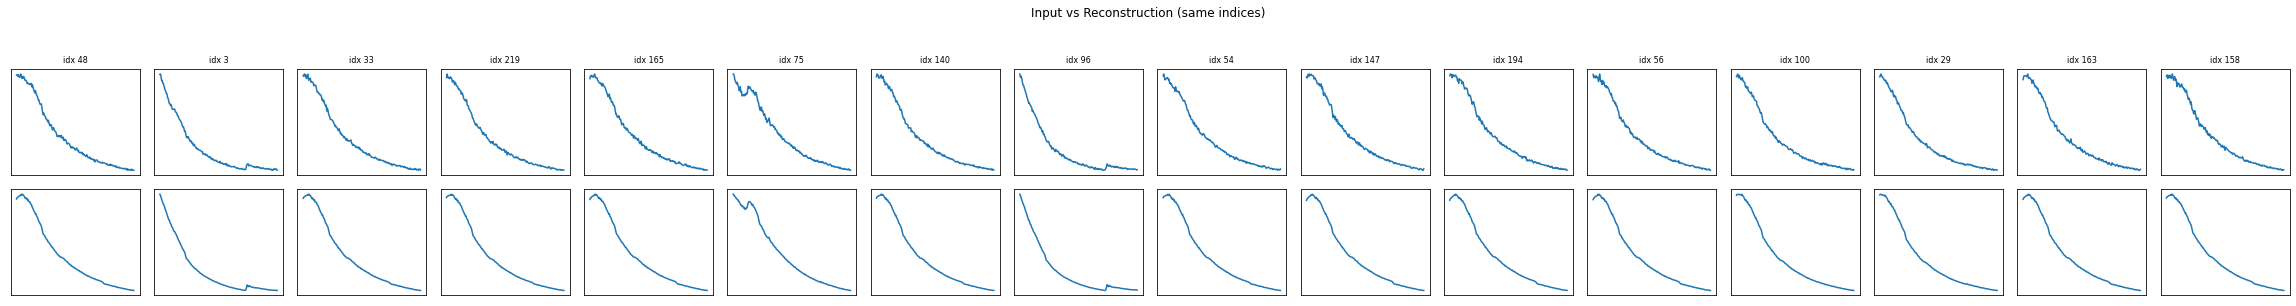

In [20]:
# we are going to visualize how the autoencoder transform the input
predictions= autoencoder.predict(test_data)
display(test_data, predictions)

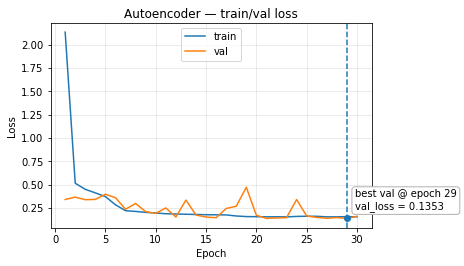

In [22]:
 
# Final Visualisation:  train/val + best epoch


train = np.array(history.history["loss"])
val   = np.array(history.history["val_loss"])
epochs = np.arange(1, len(train) + 1)

best_idx = int(np.argmin(val))          # index (0-based)
best_epoch = best_idx + 1               # epoch (1-based)
best_val = float(val[best_idx])

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(epochs, train, label="train")
ax.plot(epochs, val,   label="val")

# vertical + point + annotation au meilleur epoch (val min)
ax.axvline(best_epoch, linestyle="--")
ax.scatter([best_epoch], [best_val], zorder=3)
ax.annotate(
    f"best val @ epoch {best_epoch}\nval_loss = {best_val:.4g}",
    xy=(best_epoch, best_val),
    xytext=(8, 10),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7")
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Autoencoder — train/val loss")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

plt.show()


The validation loss appears quite noisy because the validation set is very small. You can try changing the relative sizes of the training and validation sets to make the validation curve more stable.

In [23]:
# we will use the results of best val @ epoch 25
from tensorflow.keras.models import load_model

ckpt = "runs/ae_best.h5"            
ae_best = load_model(ckpt, compile=False)
ae_best.summary()

Model: "AE_unmixing"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input (InputLayer)           [(None, 200)]             0         
_________________________________________________________________
enc_dense_9R (Dense)         (None, 27)                5427      
_________________________________________________________________
enc_lrelu_9R (LeakyReLU)     (None, 27)                0         
_________________________________________________________________
enc_dense_6R (Dense)         (None, 18)                504       
_________________________________________________________________
enc_lrelu_6R (LeakyReLU)     (None, 18)                0         
_________________________________________________________________
enc_dense_3R (Dense)         (None, 9)                 171       
_________________________________________________________________
enc_lrelu_3R (LeakyReLU)     (None, 9)                 

In [24]:
# here we "cut" the autoencoder in order to get the activations of the last hidden layer
# this layer is called "abundances_softmax" in our achitecture
# these activations correspond to the abundances maps learned by the network

encoder = tf.keras.Model(
    inputs=ae_best.input,
    outputs=ae_best.get_layer("abundances_softmax").output
)

In [25]:
# to get the abundances for all pixels,
# we run the encoder on the total image
# each row of encoded_total corresponds to the abundance vector of one pixel

encoded_total = encoder.predict(img_flat_norm)


In [26]:
# now we extract the endmembers as the decoder weights from the final Dense layer ("recon_linear").
# Each column of W.T corresponds to one estimated endmember spectrum 
# (dimension: number of energy channels).

Wd, b = autoencoder.get_layer("recon_linear").get_weights()
print("Wd shape:", Wd.shape, "b shape:", b.shape)

Wd shape: (3, 200) b shape: (200,)


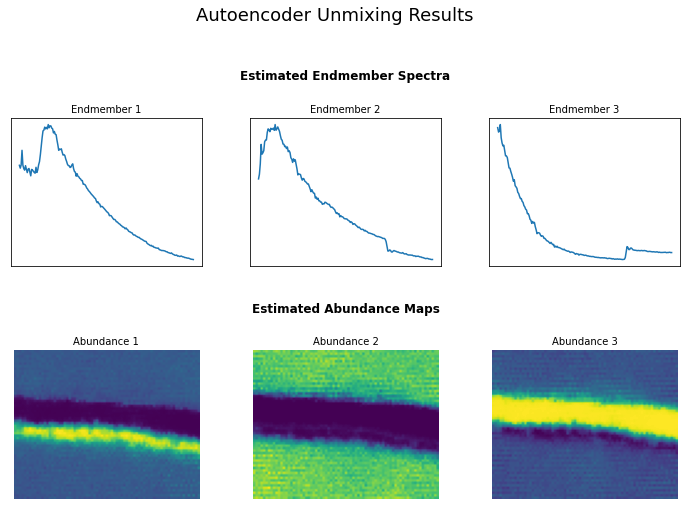

In [27]:
# R: number of endmembers
# M: (numBands, R)   endmember spectra (each column = one endmember)
# encoded_total: (N, R) abundances; reshape with (numRows, numCols)
# numRows, numCols defined elsewhere

R = 3

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(nrows=4, ncols=R, height_ratios=[0.16, 1.0, 0.16, 1.0], hspace=0.35, wspace=0.25)
fig.suptitle("Autoencoder Unmixing Results", fontsize=18, y=0.98)

# --- Row 0: subtitle for spectra (spans all columns) ---
ax_title_top = fig.add_subplot(gs[0, :])
ax_title_top.axis("off")
ax_title_top.text(0.5, 0.5, "Estimated Endmember Spectra",
                  ha="center", va="center", fontsize=12, fontweight="bold")

# --- Row 1: spectra subplots ---
for i in range(R):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(Wd[i, :])
    ax.set_title(f"Endmember {i+1}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

# --- Row 2: subtitle for abundance maps (spans all columns) ---
ax_title_bot = fig.add_subplot(gs[2, :])
ax_title_bot.axis("off")
ax_title_bot.text(0.5, 0.5, "Estimated Abundance Maps",
                  ha="center", va="center", fontsize=12, fontweight="bold")

# --- Row 3: abundance maps subplots ---
for i in range(R):
    ax = fig.add_subplot(gs[3, i])
    ax.imshow(encoded_total[:, i].reshape(numRows, numCols), cmap="viridis")
    ax.set_title(f"Abundance {i+1}", fontsize=10)
    ax.axis("off")

plt.show()



**Note on hyperparameters**

The details of the architecture and the choice of hyperparameters have a strong impact on the results.  
In practice, one can tune many aspects: batch size, learning rate, dropout rate, number of layers, etc.  

For clarity, we will not explore all of them here.  
Instead, we illustrate the point with one example — the effect of **weight initialization** — which already shows a clear difference in the unmixing results.


The choice of weight initializer has a visible impact on the unmixing results:

- **Glorot uniform (default in Keras)**  
  Produces smaller initial weights. Reconstructions are often smoother and less noisy, but endmembers can appear more similar, leading to less distinct abundance maps.

- **He normal**  
  Produces larger initial weights. This often encourages stronger separation in the latent space, so endmembers are more differentiated. However, the reconstructions may look noisier and the abundance maps less stable.

- **Take-home message**  
  Initialization is not just a technical detail: it changes the balance between *stability* (Glorot) and *discriminability* (He). For hyperspectral unmixing, both behaviors can be observed — smoother reconstructions with Glorot vs. sharper but noisier separation with He.


Training with initializer: glorot
Training with initializer: he
Training with initializer: lecun


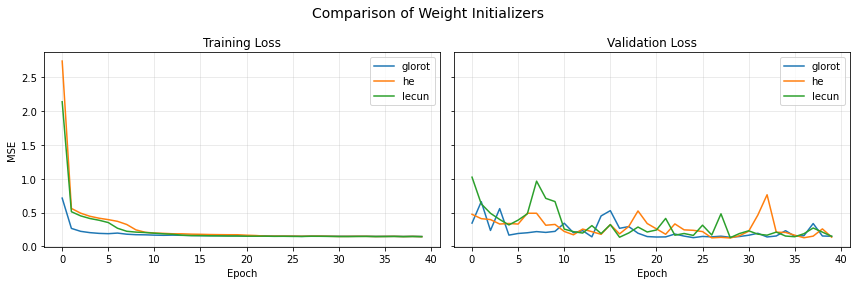

In [28]:
def train_with_init(init_mode, X_train, X_val, epochs=30, batch_size=5):
    # Re-fix the seed before each run for reproducibility
    SEED = 2025
    os.environ["PYTHONHASHSEED"] = str(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # Build model with chosen initializer
    model = build_autoencoder(num_bands=train_data.shape[1], R=3, init_mode=init_mode)
    model.compile(optimizer=optimizers.Adam(1e-3), loss=loss_function_reconstruction_1D)

    # Train quickly (no callbacks here for simplicity)
    history = model.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    return history.history

# --- Run experiments ---
histories = {}
for init_mode in ["glorot", "he", "lecun"]:
    print(f"Training with initializer: {init_mode}")
    histories[init_mode] = train_with_init(init_mode, train_data, test_data, epochs=40)

# --- Plot comparison ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for init_mode, hist in histories.items():
    ax[0].plot(hist["loss"], label=init_mode)
    ax[1].plot(hist["val_loss"], label=init_mode)

ax[0].set_title("Training Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("MSE")
ax[1].set_title("Validation Loss"); ax[1].set_xlabel("Epoch")
for a in ax: a.grid(alpha=0.3); a.legend()

fig.suptitle("Comparison of Weight Initializers", fontsize=14)
plt.tight_layout()
plt.show()


The validation loss appears quite noisy because the validation set is very small. You can try changing the relative sizes of the training and validation sets to make the validation curve more stable.

## Conclusions  
In this example we used a very simple autoencoder with only a few layers. Even with such a basic architecture, many parameters must be tuned, including data preprocessing, batch size, loss function and weight initialization.  
One of the main difficulties is that the loss value does not measure directly the unmixing quality, which must always be evaluated from the reconstructed spectra and abundances maps.  
The results are encouraging, but clearly, there is still room for improvement and further exploration.